# Trabajo Práctico 2024 - ALC

## Enunciado

### Pregunta 1 - ¿Por que la matriz A definida en (4) es equivalente a $p \ \mathbf{W} \ \mathbf{D} + e \ z^t$ ? Justificar.

Primero vamos a ver la definicion de A dada que seria la siguiente:

$a_{ij} = \begin{cases} (1-p)/n + (p \hspace{3pt} w_{ij})/c_{j} & \text{ si } c_{j} \neq 0 \\ 1/n & \text{ si } c_{j} = 0 \end{cases}$

Queremos llegar a esa expresion desde

$p \ \mathbf{W} \ \mathbf{D} + e \ z^t$

Para esto primero analizemos $p \ \mathbf{W} \ \mathbf{D}$

Sabemos que W es la matriz de conexion la cual ya esta definida, pero recordemos la definicion de D tal que:

$d_{jj} = \begin{cases} 1/c_{j} & \text{ si } c_{j} \neq 0 \\ 0 & \text{ si } c_{j} = 0 \end{cases}$

Recordemos que $D$ es una matriz diagonal que lo que va a causar es multiplicar la columna $j$ de $W$ por $1/c_{j}$. Por lo tanto nos quedaria una matriz definida como "Matriz de Puntajes" que quedaria definida de la siguiente manera

$R_{ij} = \begin{cases} w_{ij}/c_{j} & \text{ si } c_{j} \neq 0 \\ 0 & \text{ si } c_{j} = 0 \end{cases}$

Despues si como $p$ es un escalar., lo podemos multiplicar directamente quedando la siguiente definicion de $p \ \mathbf{W} \ \mathbf{D}$

$(p \ \mathbf{W} \ \mathbf{D})_{ij} = (p \ \mathbf{R})_{ij} = \begin{cases} p \hspace{3pt} w_{ij}/c_{j} & \text{ si } c_{j} \neq 0 \\ 0 & \text{ si } c_{j} = 0 \end{cases}$

Ahora que sabemos la definicion de $p \ \mathbf{W} \ \mathbf{D}$ segun $c_{j}$, analicemos $e \ z^t$ donde $e$ esta definido como una vector columna de unos de dimension $n$ y $z$ tiene la siguiente definicion

$z_{j} = \begin{cases} (1 - p)/n & \text{ si } c_{j} \neq 0 \\ 1/n & \text{ si } c_{j} = 0 \end{cases}$

como $z$ tambien es un vector columna pero que se transpone, multiplicado  por lo que queda una matriz definida de la siguiente forma

$(e \ z^t)_{ij} = \begin{cases} (1 - p)/n & \text{ si } c_{j}  \neq 0  \\ 1/n & \text{ si } c_{j} = 0 \end{cases}$

Ahora que tenemos estos dos factores por separados, vamos a juntarlos segun su condicion de $c_{j}$ lo cual nos va a dar A

$A = p \ \mathbf{W} \ \mathbf{D} + e \ z^t = a_{ij} = \begin{cases} (1-p)/n + p \hspace{3pt} w_{ij}/c_{j} & \text{ si } c_{j} \neq 0 \\ 1/n + 0 & \text{ si } c_{j} = 0 \end{cases}$

### Pregunta 2 -  ¿Cómo se garantiza existencia de la factorización $LU$? ¿ La matriz $(\mathbf{I} - p \ \mathbf{W} \ \mathbf{D})$ está bien condicionada? ¿Cómo influye el valor de $p$?

Garantizamos la existencia de una descomposicion LU si los menores pricipales son distintos de cero, es decir, que las submatrices de nuesta matriz tienen determinante no nulo.

Esto ocurre para $\forall p$ con $p$ $∈$ (0,1), para probar esto, primero queremos ver que la matriz $(\mathbf{I} - p \ \mathbf{W} \ \mathbf{D})$ a la cual llamaremos $M$, es una matriz extrictamente diagonal dominante(EDD) puesto que si esto ocurre admite descomposicion LU.

Pero en nuestro caso la que es EDD es la matriz $M^{t}$, ya que la $\sum_{j=1 con j\neq i }^{n} |a_{i,j}| < |a_{i,i}|$ (equivale a que la sumatoria de los valores de las filas en modulo, sin contar el de la diagonal, es menor que el valor de la diagonal en modulo), esto ocurre, por como esta armada nuestra matriz $M$ original, en sus columnas, ya que en las mismas simbolizan la probabilidad que tiene una pagina en especifico de ir saltando a las demas o de quedarce, en ese caso se reprecenta con el valor 1.
Entonces se puede concluir que nuestra matriz $M^{t}$ tiene descomposicion LU.

Pero tambien sabemos que el $det(M)=det(M^{t})$, por lo tanto se puede concluir que tambien la matriz $M$ admite descomposicion LU.

la matriz $M$ no esta bien condicionada, puesto que en nuestro caso $Mx=e$, pero si a esta matriz la modifico ligeramente nos quedaria $(M+\Delta)\tilde{x}=e$, y tenemos una propiedad de condicion que nos dice que:$\frac{||x-\tilde{x}||}{||x||} \leq cond_{||.||} M \frac{||M-M-\Delta ||}{M}$ que es lo mismo que decir que $\frac{||x-\tilde{x}||}{||x||} \leq cond_{||.||} M \frac{||\Delta ||}{M}$


Como obsevamos que cuanto mayor es $p$, mayores son los numeros en modulo por fuera de la diagonal. Ademas calculamos las condiciones de norma 2, 1 e infinito  con nuestros test. Estos nos mostro que mientras menor es la $p$, mejor condicionada es nuestra matriz y mientras mayor es la $p$, peor condicionada se vuelve.

Por lo tanto esta valor $cond_{||.||}$ de nustra propiedad va a crecer y en efecto crece muy rapido a medida que aumenta $p$ (ver grafico mas adelante en el codigo, hecho para diferentes normas).

Entonces para pequeñas modificaciones de mi matriz, la solucion de la matriz original vs la modificada puede variar mucho, lo cual no es lo que uno esperaria.

**IMPLEMENTACION**

Implementar la factorización $LU$ para resolver el sistema de ecuaciones (6) que permite hallar la solución buscada (es decir, el ranking de páginas). Se podrá utilizar la función **scipy.linalg.solve_triangular** para resolver sistemas triangulares.

En el siguiente cuerpo de la notebook se genera un test que va a evaluar la función que resuelve el sistema a través de un test unitario. La resolución debe realizarse en el archivo **funciones.py** que acompaña el **template-alumnos**.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy import linalg
import seaborn as sns
import seaborn.objects as so
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import time
from timeit import default_timer as timer
import random

#Funciones del archivo
def leer_archivo(input_file_path):

    f = open(input_file_path, 'r')
    n = int(f.readline())
    m = int(f.readline())
    W = np.zeros(shape=(n,n))
    for _ in range(m):
        line = f.readline()
        i = int(line.split()[0]) - 1
        j = int(line.split()[1]) - 1
        W[j,i] = 1.0
    f.close()

    return W

def dibujarGrafo(W, print_ejes=True):
    options = {
    'node_color': 'yellow',
    'node_size': 200,
    'width': 3,
    'arrowstyle': '-|>',
    'arrowsize': 10,
    'with_labels' : True}

    N = W.shape[0]
    G = nx.DiGraph(W.T)

    #renombro nodos de 1 a N
    G = nx.relabel_nodes(G, {i:i+1 for i in range(N)})
    if print_ejes:
        print('Ejes: ', [e for e in G.edges])

    nx.draw(G, pos=nx.spring_layout(G), **options)

def calcularRanking(M, p):
    npages = M.shape[0]
    rnk = np.arange(0, npages) # ind{k] = i, la pagina k tienen el iesimo orden en la lista.
    scr = np.zeros(npages) # scr[k] = alpha, la pagina k tiene un score de alpha
    # CODIGO

    U, L = resolverLU(matrizLU(M, p))

    e = np.ones((npages, 1))

    #Solucion al Sistema con la factorizacion LU
    y = linalg.solve_triangular(L, e, lower = True)
    x = normalize(linalg.solve_triangular(U, y))

    scr = x

    # Ordeno ranking segun los scores
    rnk = sorted(rnk, key=lambda k: scr[k], reverse=True)

    return rnk, scr

def obtenerMaximoRankingScore(M, p):
    output = -np.inf
    # calculo el ranking y los scores
    rnk, scr = calcularRanking(M, p)
    output = np.max(scr)

    return output

#Nuestras Funciones
def vectorGrado(M):
    # calculo del Vector Grado
    # Dependende de la Matriz de Conexion

    C = np.zeros(len(M))

    for m in range(0, len(M)):
        for n in range(0, len(M)):
            C[m] += M[n][m]

    return C

def matrizA(M, p):
    # Calculo de la Matriz A segun su definicion
    # Dependencia de la Matriz de Conexion y de la Probabilidad

    C = vectorGrado(M)
    A = np.zeros([len(M),len(M)])

    for m in range(0, len(M)):
        for n in range(0, len(M)):
            if C[n] != 0:
                A[m][n] = ((1 - p)/len(M))+((p * M[m][n])/C[n])
            else:
                A[m][n] = 1/len(M)

    return A

def solucionA(M, p):
    # Calculo de la Solucion a A
    # Dependencia de la Matriz de Conexion y de la Probabilidad

    A = matrizA(M, p)
    X = np.ones(len(M)) / len(M)

    X = A @ X

    return normalize(X)

def matrizD(C):
    # Calculo de la matriz de D por Definicion la cual es diagonal
    # Dependencia del Vector de Grado

    D = np.zeros([len(C),len(C)])

    for m in range(0, len(C)):
        if C[m] != 0:
            D[m][m] = 1/C[m]

    return D

"""
def vectorZ(M, C, p):
    z = np.zeros(len(M))

    for m in range(0, len(M)):
        if C[m] != 0:
            z[m] = (1 - p)/len(M)
        else:
            z[m] = 1/len(M)

    return z
"""

def matrizLU(M, p):
    #Calculo de la matriz para el calculo de LU
    #Depende de la Matriz de Conexion y de la probabilidad

    R = matrizPuntajes(M)

    A = np.eye(len(M)) - p*R

    """
    D = matrizD(vectorGrado(M))

    A = np.identity(len(M)) - p * (M @ D)
    """

    return A

def pivoteo_partial(A):
    #Calculo de P para despje PA=LU, no se uso al final
    #Depende de la matrizLU calculandose

    P = np.identity(len(A))
    for j in range(0,len(A)): #recorre columna
        max_col = 0
        pos_fila_max = j #indice de la columna actual
        for i in range(j, len(A)): #recorre fila
            if np.abs(A[i][j]) > max_col:
                max_col = np.abs(A[i][j])
                pos_fila_max = i

        P[[j, pos_fila_max]] = P[[pos_fila_max,j]]
    return P

def resolverLU(A):
    #Resolucion de la factorizacion LU
    #Depende de la la matrizLU a despejar

    Ac = np.copy(A)
    N = len(Ac)
    TCompleto = np.zeros([N,N])

    for j in range (0, N):
        #P = pivoteo_partial(A)
        #U = P @ U
        T = np.zeros([N,N])

        for i in range(j+1, N):
            T[i, j] = - Ac[i, j] / Ac[j, j]
            Ac[i, j:] += T[i, j] * Ac[j, j:]

        TCompleto += T

    Ac -= TCompleto

    L = np.tril(Ac,-1) + np.eye(A.shape[0])
    U = np.triu(Ac)

    return U,L

def normalize(X):
    #Normalizacion de vector con norma 1
    #Depende de un vector dado

    norm = np.linalg.norm(X, 1)
    return  X / norm


def matrizPuntajes(W):
    #Calculo de la matriz R dada por Defincion
    #Depende solo de la matriz de Conexion

    npages = W.shape[0]
    D = np.eye(npages) # genero D
    grados = vectorGrado(W) # genero array de grados

    for j in range(npages):
      if grados[j] == 0: # evitamos la division por 0
        D[j][j] = 0
      else:
        D[j][j] /= grados[j]

    R = W @ D

    return R

def pagmaxScore(W,p):
    rnk, scr=calcularRanking(W, p)
    pagMaxScore=[]
    cantDeMax=0
    for i in range(0,len(scr)):
        if obtenerMaximoRankingScore(W, p)== scr[i]:
           pagMaxScore.append(i+1)
           cantDeMax=cantDeMax+1
    return pagMaxScore,cantDeMax

def tiempo_ejecucion(W, p):
    ##Funcion para calcular el tiempo de ejecucion de "calcularRanking"

    ti = timer()

    rnk, scr=calcularRanking(W, p)
    calcularRanking(W, p)

    tf = timer()

    deltaT = tf - ti
    return deltaT

def densidadDeNodos(W, p):
    #Calculo de la densidad de los nodos nuestro sistema
    #Depende de la matriz de conexion
    densidad=0
    for i in range(0,len(W)):
        for j in range(0,len(W)):
            if W[i][j]==1:
               densidad+=1
    return densidad

def maximoRank(scr, rnk):
    #Calculo de los nodos con mayor score
    #Depende de los ya calculados Puntajes y Ranking
    procesarMaximos = True
    maximos = [rnk[0]+1]
    i = 1

    while procesarMaximos == True:
        if np.isclose(scr[rnk[0]] - scr[rnk[i]], 0):
            maximos.append(rnk[i]+1)
        else:
            procesarMaximos = False
        i += 1

        if i == len(rnk):
            procesarMaximos = False

    return maximos

def condicionUno(W):
    return (np.linalg.norm(W,1)) * (np.linalg.norm(np.linalg.inv(W),1))

def condicionInf(W):
    return (np.linalg.norm(W, np.inf)) * (np.linalg.norm(np.linalg.inv(W), np.inf))

def condicion(W):
    return (np.linalg.norm(W)) * (np.linalg.norm(np.linalg.inv(W)))

En el siguiente bloque de codigo,observamos que el numero de condicion aumenta drasticamente a medida que aumenta la probabilidad

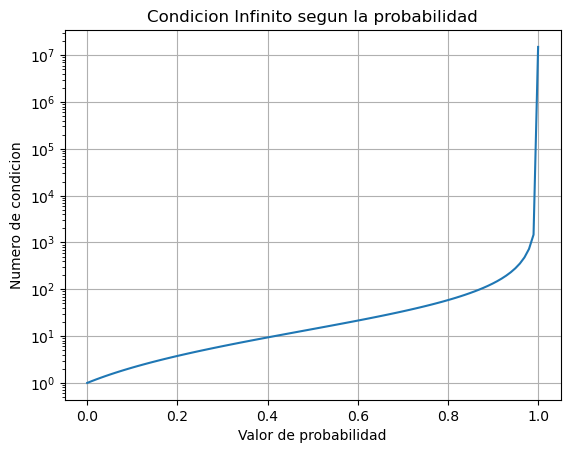

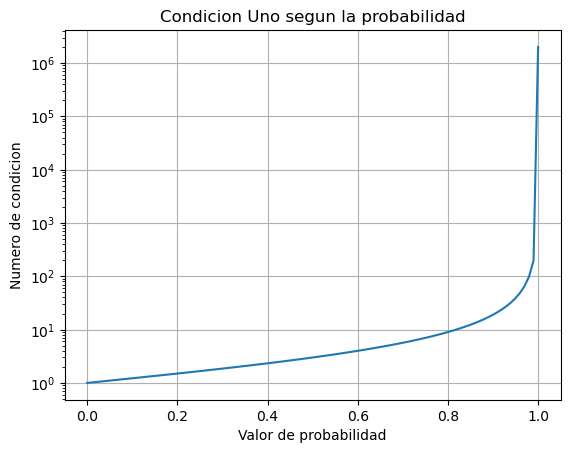

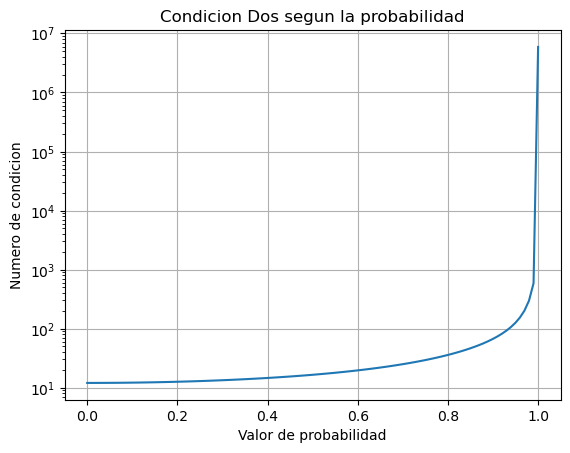

In [2]:
p = np.linspace(0, 0.999999, 100)

for j in range (0,3):
    n_condicion = []

    for i in range(0,len(p),1):
        archivo_test = 'tests/test_dosestrellas.txt'
        W = leer_archivo(archivo_test)
        M=np.identity(len(W))-p[i]*matrizPuntajes(W)

        if j == 0:
            n_condicion.append(condicionInf(M))

            title = 'Condicion Infinito segun la probabilidad'
        elif j == 1:
            n_condicion.append(condicionUno(M))

            title = 'Condicion Uno segun la probabilidad'
        else:
            n_condicion.append(condicion(M))

            title = 'Condicion Dos segun la probabilidad'


    plt.figure()
    plt.plot(p, n_condicion)
    plt.xlabel('Valor de probabilidad')
    plt.ylabel('Numero de condicion')
    plt.title(title)
    plt.yscale('log')
    plt.grid()
    plt.show()

### Test Unitario
En el archivo funciones.py hay que implementar la función que obtienen el ranking de las páginas.
Se espera que el llamado a la siguiente función arroje un valor esperado

**************************************************
Test unitario 1
BIEN! - Paso correctamente el test unitario
**************************************************


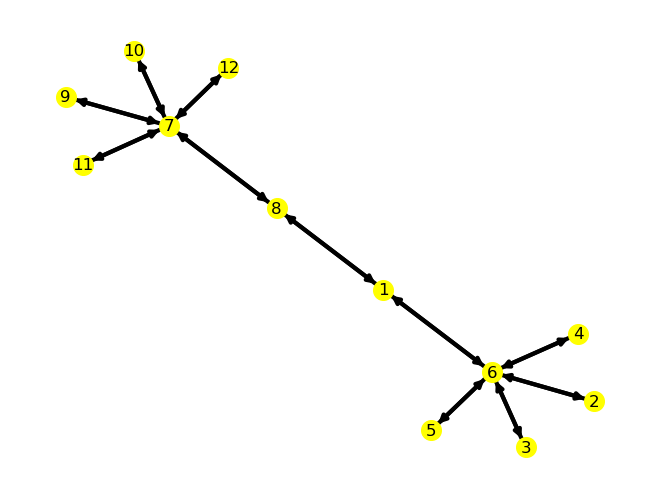

In [3]:
#ARCHIVOS DE ENTRADA
archivo_test = 'tests/test_dosestrellas.txt'

#CARGA DE ARCHIVO EN GRAFO
W = leer_archivo(archivo_test)

dibujarGrafo(W, print_ejes=False)

# defino la probabilidad de salto de continuar los links de la pagina actual
p = 0.5
# Realizo el test unitario para el calculo del mayor score, que pruebe que el codigo funciona correctamente.
print('*'*50)
print('Test unitario 1')

#Nos dio el siguiente valor pero aun asi falla el test 0.1811594202898551
try:
    assert(np.isclose(obtenerMaximoRankingScore(W, p), 0.1811,atol=1e-4))
except:
    print('OUCH!! - No paso el test unitario')
else:
    print('BIEN! - Paso correctamente el test unitario')
print('*'*50)
#print(np.identity(len(W))-p*matrizPuntajes(W))

### Test Unitarios Adicionales

El grupo **deberá** proponer al menos 3 instancias de prueba no triviales, dos de las cuales deben ser de tipo TODOS LOS NODOS CONECTADOS, y otra de tipo NINGUNO CONECTADO. La tercera instancia queda a criterio del grupo.

Para el análisis, guiarse y responder las siguientes preguntas:

* ¿Cómo es el ranking obtenido en cada caso de acuerdo a la estructura del grafo páginas?
* ¿Qué conclusiones pueden sacar de la interpretación de los resultados?

Graficar los grafos usando las funciones en el **funciones.py**.

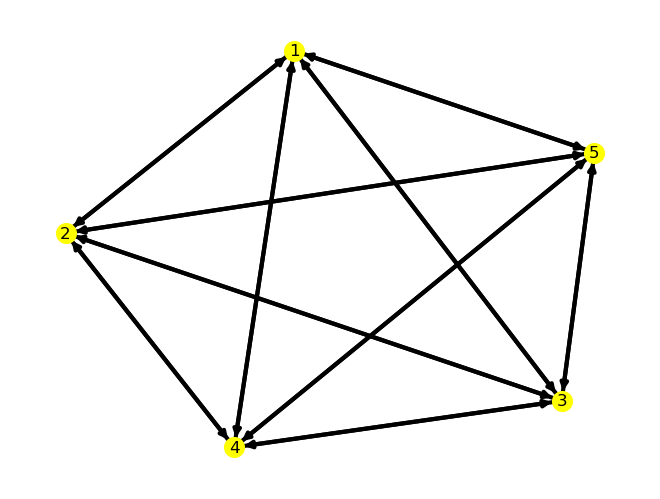

paginas con maximo Score: [1, 2, 3, 5, 4]
MaximoRankingScore: [0.2]
cantidad de maximos encontrados: 5
Ranking en orden:
nodo  1  :  [0.2]
nodo  2  :  [0.2]
nodo  3  :  [0.2]
nodo  5  :  [0.2]
nodo  4  :  [0.2]


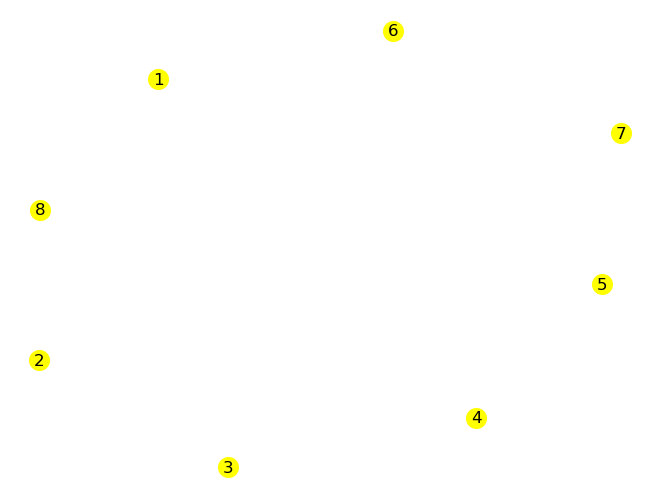

paginas con maximo Score: [1, 2, 3, 4, 5, 6, 7, 8]
MaximoRankingScore: [0.125]
cantidad de maximos encontrados: 8
Ranking en orden:
nodo  1  :  [0.125]
nodo  2  :  [0.125]
nodo  3  :  [0.125]
nodo  4  :  [0.125]
nodo  5  :  [0.125]
nodo  6  :  [0.125]
nodo  7  :  [0.125]
nodo  8  :  [0.125]


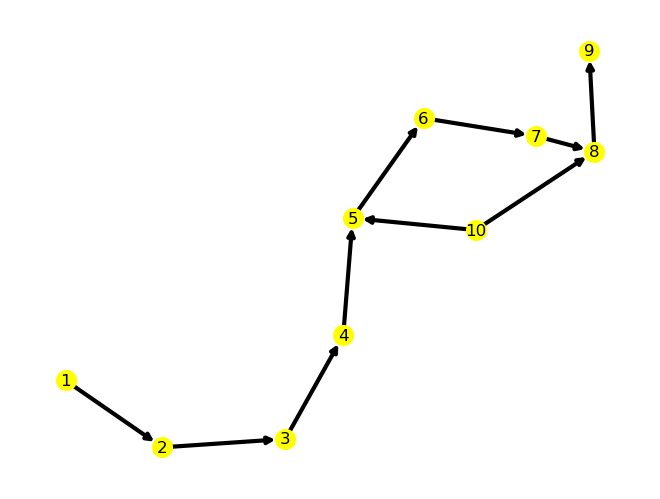

paginas con maximo Score: [8]
MaximoRankingScore: [0.12726875]
cantidad de maximos encontrados: 1
Ranking en orden:
nodo  8  :  [0.12726875]
nodo  5  :  [0.12245791]
nodo  9  :  [0.11961513]
nodo  6  :  [0.11720971]
nodo  7  :  [0.11458561]
nodo  4  :  [0.10496392]
nodo  3  :  [0.09796632]
nodo  2  :  [0.08397113]
nodo  1  :  [0.05598076]
nodo  10  :  [0.05598076]


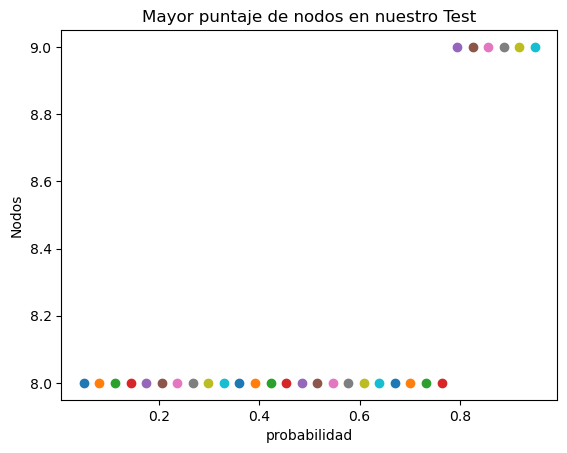

In [4]:
#ARCHIVOS DE ENTRADA
archivo_test= ['tests/test_todos_conectados.txt', 'tests/test_ninguno_conectado.txt', 'tests/test_a_eleccion.txt']


claves=['todos_conectados','ninguno_conectados','test_a_eleccion']

p=0.5

for i in range(len(claves)):
    W = leer_archivo(archivo_test[i])
    plt.show()

    dibujarGrafo(W, print_ejes=False)
    plt.show()
    rnk, scr=calcularRanking(W, p)

    maximos = maximoRank(scr, rnk)

    print("paginas con maximo Score:", maximos)
    print("MaximoRankingScore:", scr[rnk[0]])
    print("cantidad de maximos encontrados:", len(maximos))
    print("Ranking en orden:")

    for j in range(len(scr)):
        print("nodo ", rnk[j]+1 , " : ", scr[rnk[j]])

    if i == 2:
        for j in np.linspace(0.05,0.95,30):
            rnk, scr = calcularRanking(W, j)
            pagMaxScore = maximoRank(scr, rnk)

            for max in pagMaxScore:
                plt.scatter(j,max)

        plt.ylabel( 'Nodos')
        plt.xlabel('probabilidad')
        plt.title("Mayor puntaje de nodos en nuestro Test")
        plt.yticks(rotation=0)
        plt.show()


Para los casos de "Todos Conectados" y "Ninguno Conectado" estas 2 matrices comparten que todos sus nados tienen el mismo puntaje para todo $p$ que elijamos que es equivalente a $1/cant(nodos)$, vemos que en el primer caso tiene probabilidades identicas de saltar a cualquier pagina lo que seria como "un salto al azar" pues estan todos conactados con todos, esto tambien ocurren el el otro caso, pues ninguno esta conectado entre si, entonces aleatoriamente puede saltar a cualquiera.

En nuestro caso de prueba, observamos que la pagina 9 es la mejor rankiada para probabilidad $p$ alta, esto significa que cuando las paginas tienden a seguir los link de la pagina 9 es la mejor, esto es esperable ya que recibe importancia de todas las demas paginas.

Vemos que para probabilidades bajas, hasta casi $p=0.8$, la pagina mejor rankiada es la 8 y luego va a cambiar a la 9, esto se debe a que con $p$ bajas las paginas tienen mas posibilidad de no seguir los link, y la pag 8 esta influenciada tambien por la 10, lo que no ocurre con la 9.

Tambien observamos que la pag 1 y 10 que serian las mas aisladas ya que la 1 no recibe ningun link y la 10 tampoco, son las menos rankiadas


---

## Enunciado

Sobre los casos de test que se encuentran en el folder `tests`, se pide realizar los análisis siguientes para todos los grafos del folder.

### Análisis Cuantitativo

Para el análisis cuantitativo, se pide, como mínimo, estudiar los tiempos de procesamiento en función del tamaño del grafo de páginas y de la densidad del mismo. Para esto, se espera que presenten gráficos mostrando los tiempos de ejecución para obtener la solución en función de la cantidad de nodos/links de diferentes grafos de páginas aleatorios.


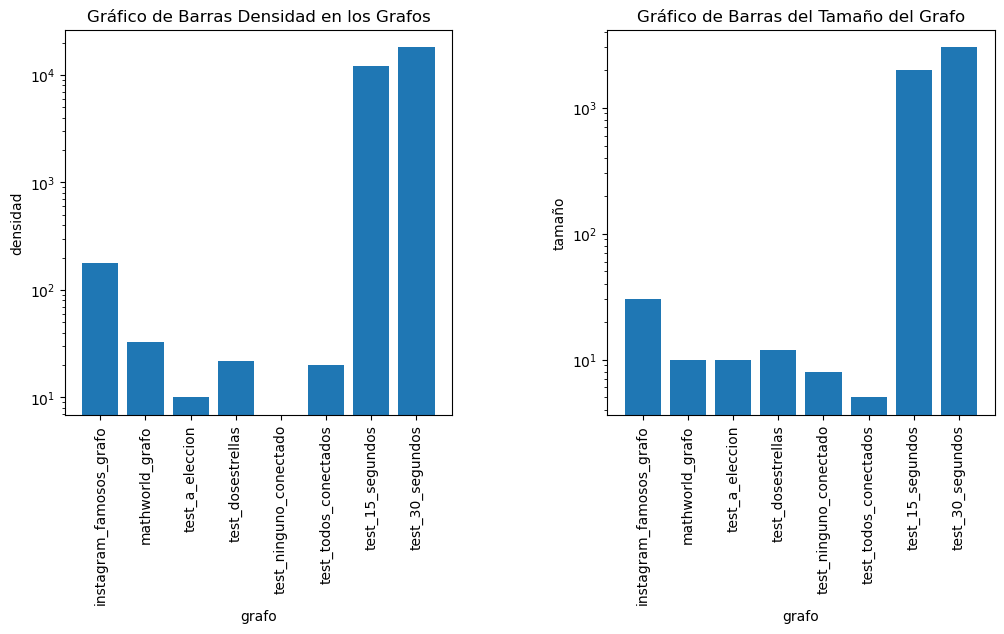

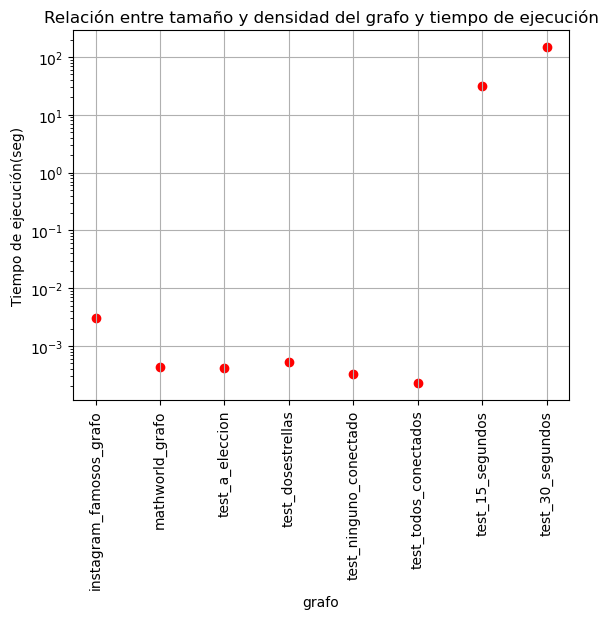

In [5]:
archivo_test= ['tests/instagram_famosos_grafo.txt', 'tests/mathworld_grafo.txt', 'tests/test_a_eleccion.txt',
          'tests/test_dosestrellas.txt','tests/test_ninguno_conectado.txt','tests/test_todos_conectados.txt',
             'tests/test_15_segundos.txt','tests/test_30_segundos.txt']


claves=['instagram_famosos_grafo','mathworld_grafo','test_a_eleccion',
       'test_dosestrellas','test_ninguno_conectado','test_todos_conectados',
        'test_15_segundos', 'test_30_segundos']

p=0.5

valores = []
grafos_densidad = {}
grafos_nodos = {}
# diccionario de densidades
for i in range(len(claves)):
    W = leer_archivo(archivo_test[i])
    valores.append(densidadDeNodos(W, p))
    grafos_densidad[claves[i]] = valores[i]

# diccionario de tamaños
valores = []
for i in range(len(claves)):
    W = leer_archivo(archivo_test[i])
    valores.append(len(W))
    grafos_nodos[claves[i]] = valores[i]

# lista de tiempos
segundos=[]
for i in range(len(claves)):
    W = leer_archivo(archivo_test[i])
    segundos.append(tiempo_ejecucion(W, p))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(grafos_densidad.keys(), grafos_densidad.values())
ax1.set_xlabel('grafo')
ax1.set_ylabel('densidad')
ax1.set_title('Gráfico de Barras Densidad en los Grafos')
ax1.set_yscale('log')
plt.setp(ax1.get_xticklabels(), rotation=90)

ax2.bar(grafos_nodos.keys(), grafos_nodos.values())
ax2.set_xlabel('grafo')
ax2.set_ylabel('tamaño')
ax2.set_title('Gráfico de Barras del Tamaño del Grafo')
ax2.set_yscale('log')
plt.setp(ax2.get_xticklabels(), rotation=90)

plt.subplots_adjust(wspace=0.4)
plt.show()

plt.scatter(grafos_nodos.keys(), segundos, color='red')#, label='Tiempos')
plt.xlabel('grafo')
plt.ylabel('Tiempo de ejecución(seg)')
plt.title('Relación entre tamaño y densidad del grafo y tiempo de ejecución')
plt.xticks(rotation=90)
plt.yscale('log')
plt.grid()

plt.show()


Observamos que para los tests: *mathworld_grafo, a_eleccion,  dosestrellas, ninguno_conectado, todos conectados*, todos pequeños tamaños de grafos (cant de paginas/nodos) y densidades cercanas (link/conexiones entre paginas/nodos). Por lo tanto los tiempos que tarda en ejecutarce el programa son bastante cercanos.

Tambien se puede contemplar que a mayor tamaño/densidad, crece drasticamente el tiempo de ejecucion del programa, esto se puede ver en los casos de tests: *instagram_famosos_grafo*, *15_segundos* y *30_segundos*.

Ahora analizaremos grafos aleatorios con diferentes densidades de link, pero con el mismo tamaño, para ver como influye esta carecteristica con los tiempos de ejecucion.

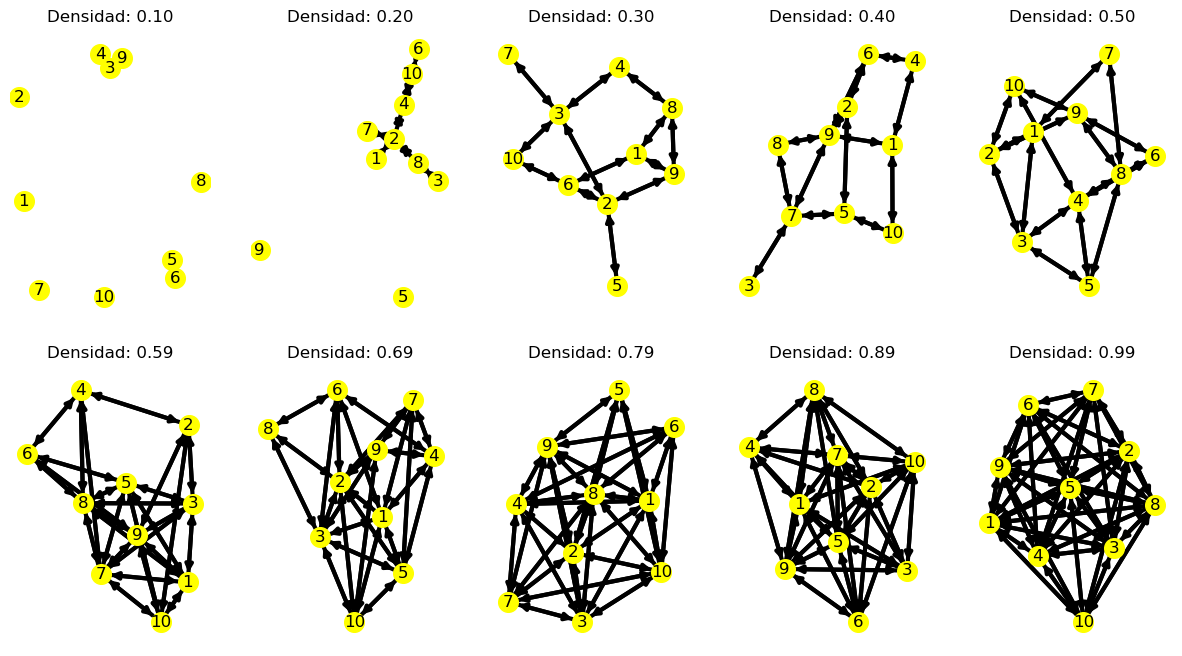

In [6]:
#codigo de prueba para ver como aumentan las densidades, con un tamaño fijo de nodos
#con pocos puntos
densidades = np.linspace(0.1, 0.99, 10)
tiempos = []

fig, axs = plt.subplots(2, 5, figsize=(15, 8))
axs = axs.ravel()

for i, densidad in enumerate(densidades):
    n = 10
    p = 0.5
    W = nx.to_numpy_array(nx.erdos_renyi_graph(n, densidad))
    tiempo = tiempo_ejecucion(W, p)
    tiempos.append(tiempo)

    # Dibuja el grafo en el subplot correspondiente
    G = nx.DiGraph(W.T)
    G = nx.relabel_nodes(G, {i:i+1 for i in range(n)})
    options = {
        'node_color': 'yellow',
        'node_size': 200,
        'width': 3,
        'arrowstyle': '-|>',
        'arrowsize': 10,
        'with_labels': True
    }
    axs[i].set_title(f"Densidad: {densidad:.2f}")
    nx.draw(G, pos=nx.spring_layout(G), ax=axs[i], **options)



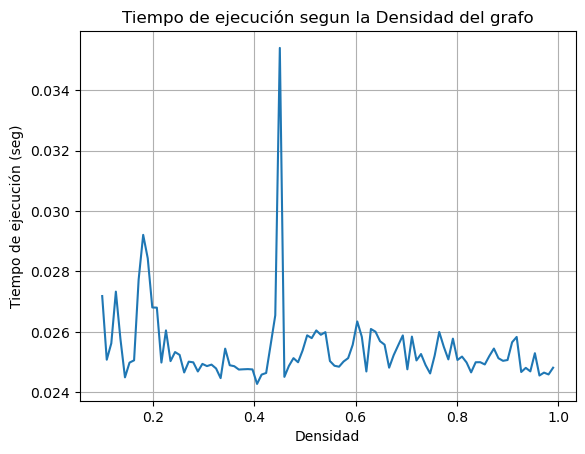

In [7]:
#grafos aleatorios con diferentes densidades
densidades = np.linspace(0.1, 0.99, 100)
tiempos = []

for densidad in densidades:
    n = 100
    p = 0.5
    W = nx.to_numpy_array(nx.erdos_renyi_graph(n, densidad))
    tiempo = tiempo_ejecucion(W, p)
    tiempos.append(tiempo)

plt.figure()
plt.plot(densidades, tiempos)
plt.xlabel('Densidad')
plt.ylabel('Tiempo de ejecución (seg)')

plt.title('Tiempo de ejecución segun la Densidad del grafo')
plt.grid()
plt.show()

Observamos que el tiempo de ejecucion no depende especificamente de la densidad, ya que los valores del tiempo varian poco entre si, van entre $0.026$ y $0.040$ segundos, por este motivo deducimos que lo que produce un cambio importante en el tiempo de ejecucion del programa es el tamaño del grafo y no la densidad entre sus nodos, esto ultimo lo analizaremos en el siguiente bloque de codigo

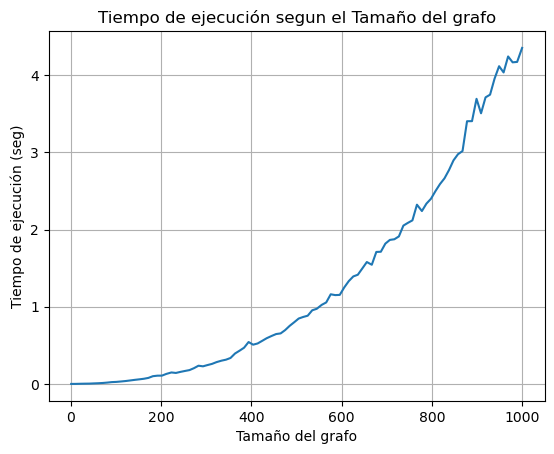

In [8]:
#grafos aleatorios con diferentes tamaños
tamaños = np.linspace(1,1000, 100, dtype=int)
tiempos = []

for n in tamaños:
    p = 0.5
    densidad = 0.5
    W = nx.to_numpy_array(nx.erdos_renyi_graph(n, densidad))
    tiempo = tiempo_ejecucion(W, p)
    tiempos.append(tiempo)

plt.figure()
plt.plot(tamaños, tiempos)
plt.xlabel('Tamaño del grafo')
plt.ylabel('Tiempo de ejecución (seg)')
plt.title('Tiempo de ejecución segun el Tamaño del grafo')
plt.grid()
plt.show()

Efectivamente el tamaño del grafo es lo que aumenta el tiempo de ejecucion.

### Análisis Cualitativo

Para el análisis cualitativo se deberán estudiar los rankings obtenidos, en función de la estructura del grafo, y del valor de $p$. Para esto, se espera que presenten gráficos mostrando las probabilidades de las páginas mejor rankeadas en función del valor de $p$.


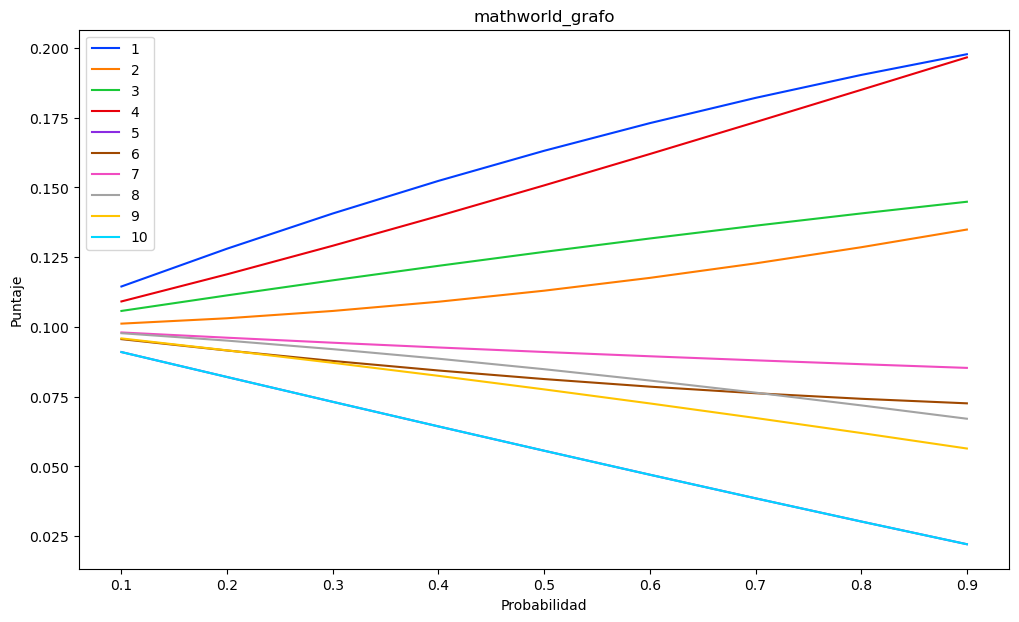

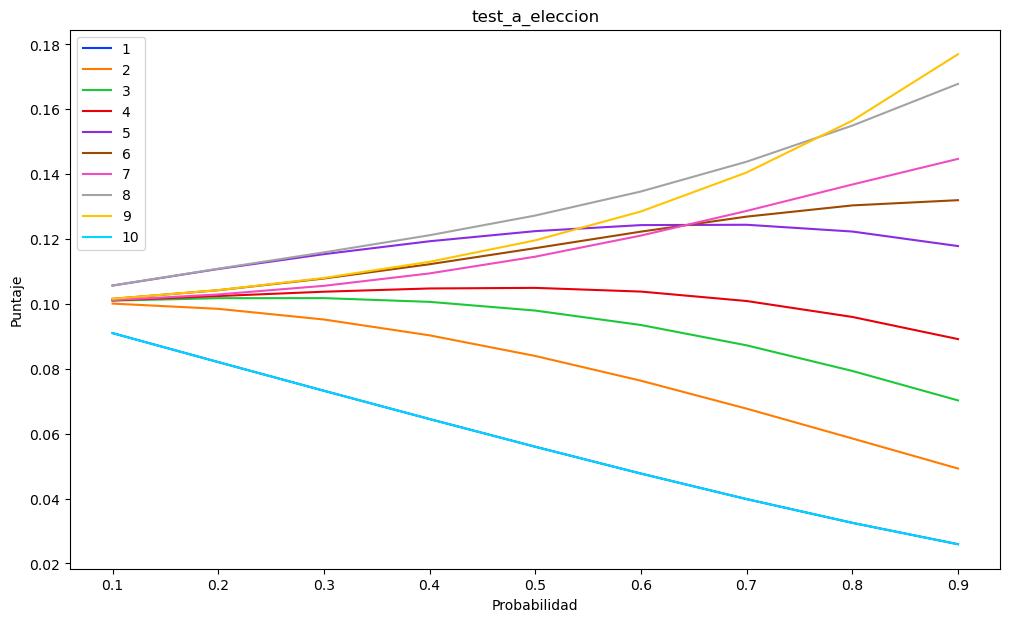

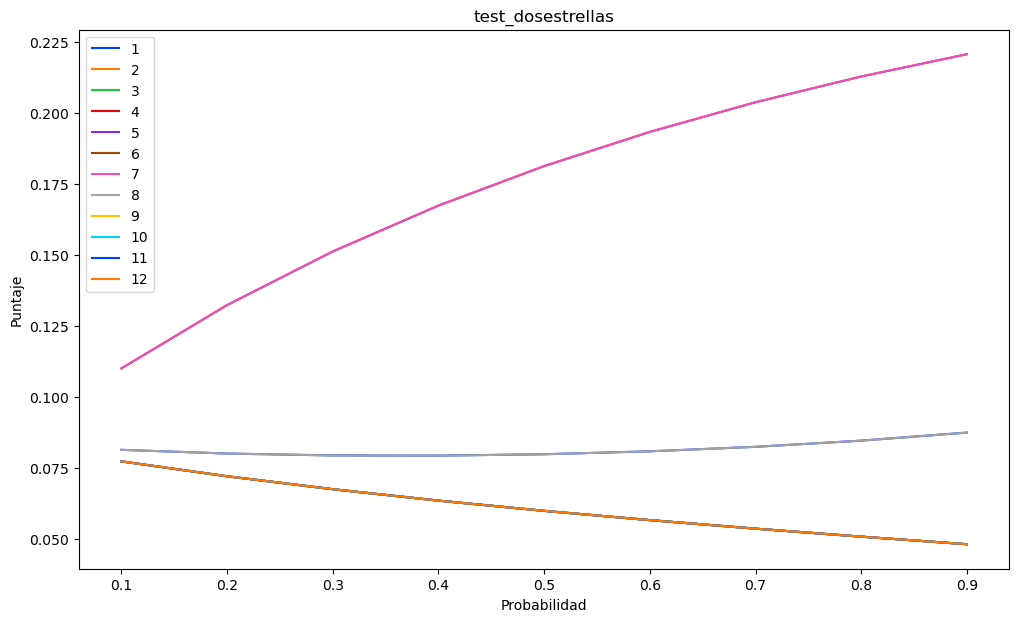

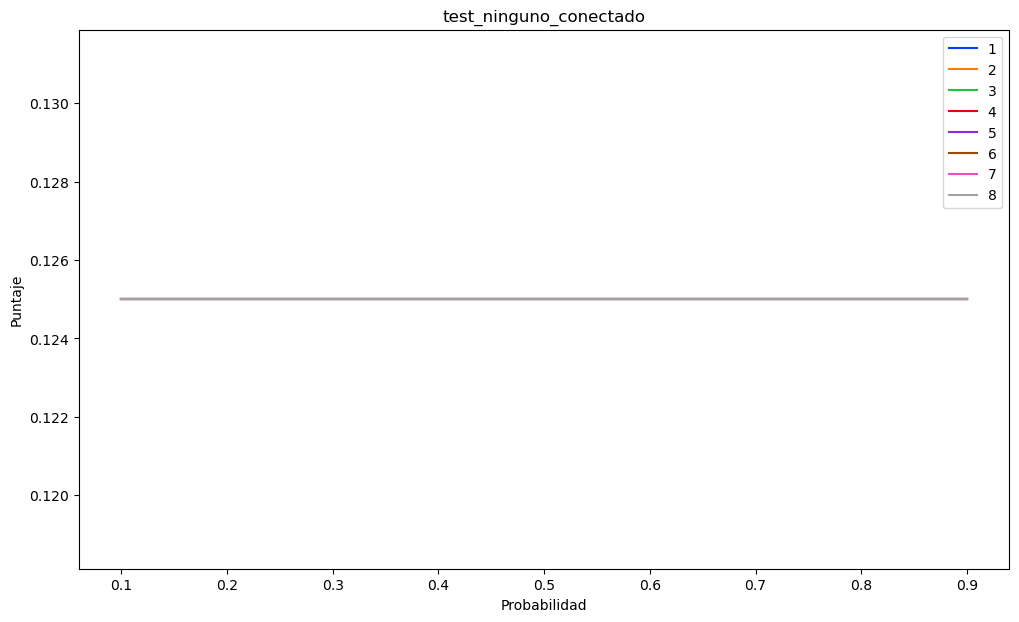

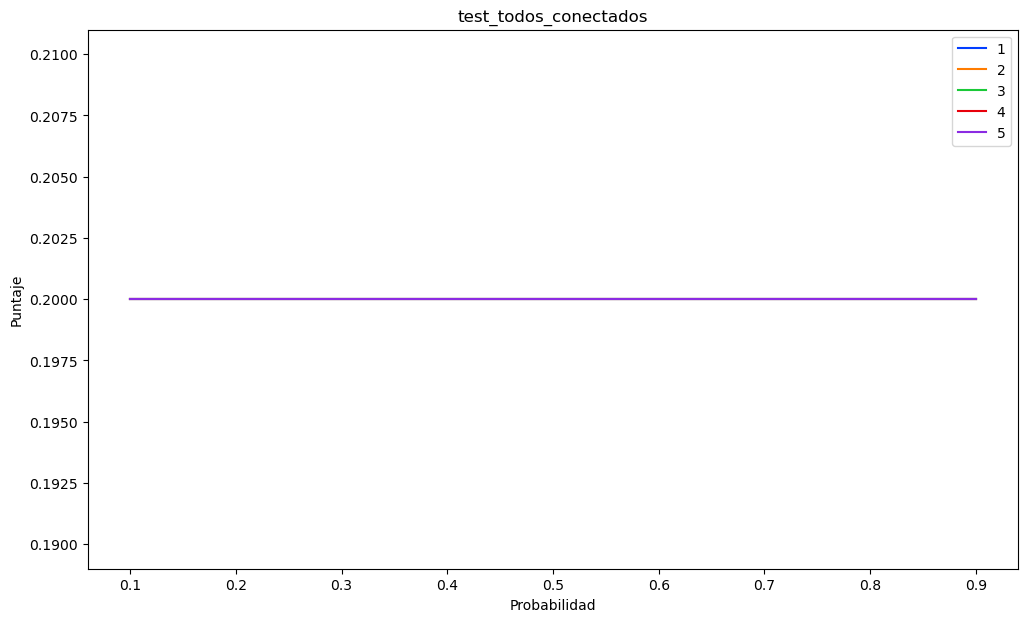

In [9]:
#Variables
archivo_test= ['tests/mathworld_grafo.txt', 'tests/test_a_eleccion.txt','tests/test_dosestrellas.txt',
               'tests/test_ninguno_conectado.txt','tests/test_todos_conectados.txt' ]

claves=['mathworld_grafo','test_a_eleccion','test_dosestrellas',
        'test_ninguno_conectado','test_todos_conectados']

p = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

#Codigo

for i in range(0, len(archivo_test)):
    W = leer_archivo(archivo_test[i])

    dataset = pd.DataFrame(columns=np.arange(1, len(W)+1))

    for porcentaje in p:
        rnk, scr = calcularRanking(W, porcentaje)

        puntajes = pd.DataFrame(scr.transpose(), columns=np.arange(1, len(W)+1))

        dataset = pd.concat([dataset, puntajes], axis=0, ignore_index=True)

    dataset = pd.concat([dataset, pd.DataFrame(p, columns=["porcentaje"])], axis=1)

    columns = np.arange(0, len(W))

    fig, ax = plt.subplots(figsize=(12, 7))

    sns.lineplot(x='porcentaje', y='value', hue='variable',
                data=pd.melt(dataset, ['porcentaje']),
                palette=sns.color_palette("bright", len(W)))

    plt.xlabel('Probabilidad')
    plt.ylabel('Puntaje')
    plt.title(claves[i])
    plt.legend()
    plt.show()

En estos grafico observamos como para diferentes probabilidades, como va cambiando el score y por lo tanto el ranking entre ellas, tambien vemos como algunas paginas comparten puntuacion, quedando solapadas entre ellas. El grafico donde vemos que es mas evidente el cambio de ranking es el "test_a_eleccion", donde cambian en diferentes probabilidades el ranking de las paginas como pudimos observar en su test unitario.

### Dos estrellas

Para el caso **test_dosestrellas.txt** se pregunta:

¿Cuál es la mínima cantidad de links que se deben agregar para que la pagina correspondiente al nodo 1 quede primera en el ranking? ¿ Cómo se modificó la conectividad? Analizar.



La mínima cantidad de links que se deben agregar para que la pagina correspondiente al nodo 1 quede primera en el ranking son 6 conexiones nuevas con dicha pagina.

Primero intentamos conectar todos los nodos de la puntuacion mas alta a uno pero eso causaba que el nodo 7 siempre lo superara. Por lo tanto conectamos los nodos con menor cantidad de conexiones y mas puntaje entre los nodos que teniamos, el resultado es la siguiente evolucion de grafos donde se puede ver como fuimos agregandole poco a poco mas puntuacion al uno. Estas conexiones fueron las siguiente:

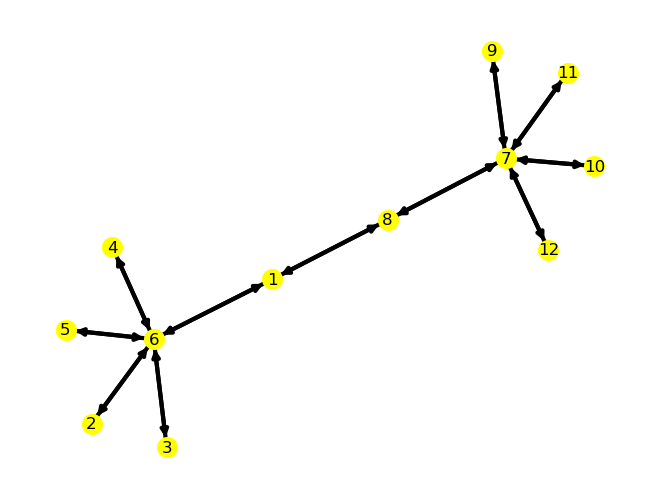

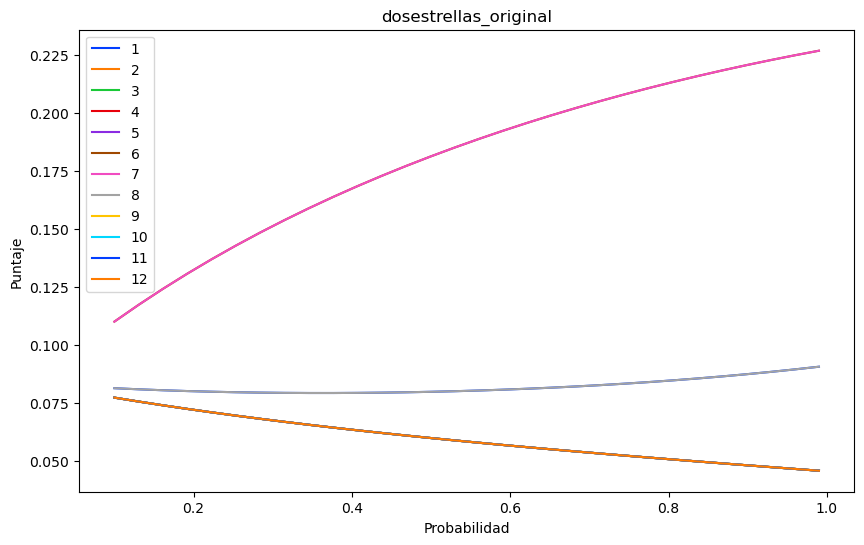

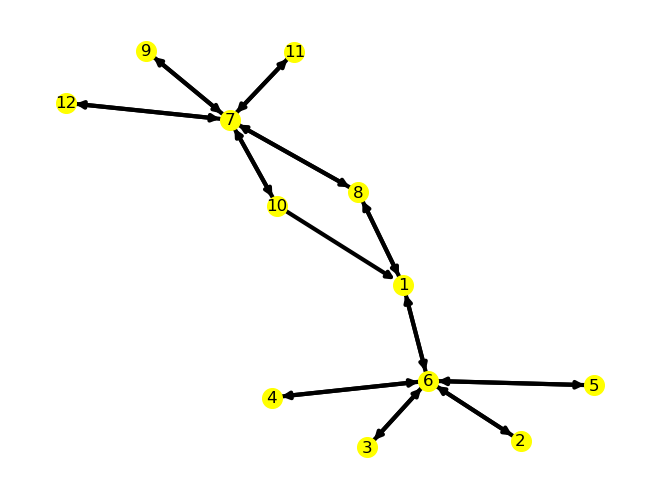

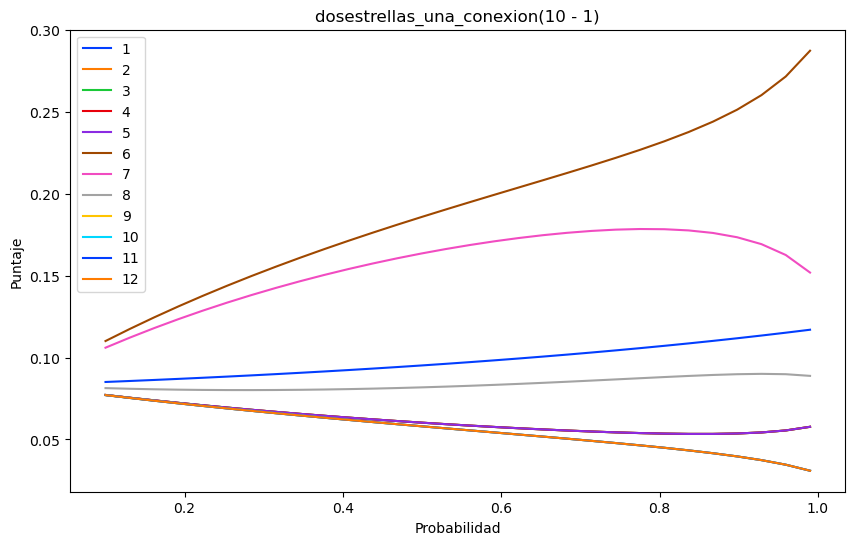

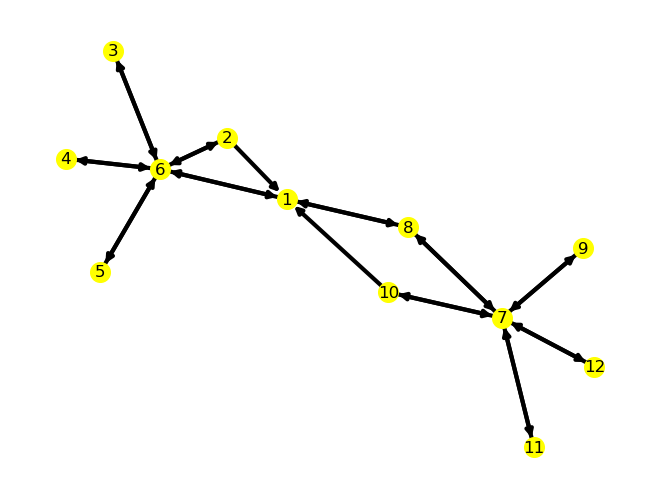

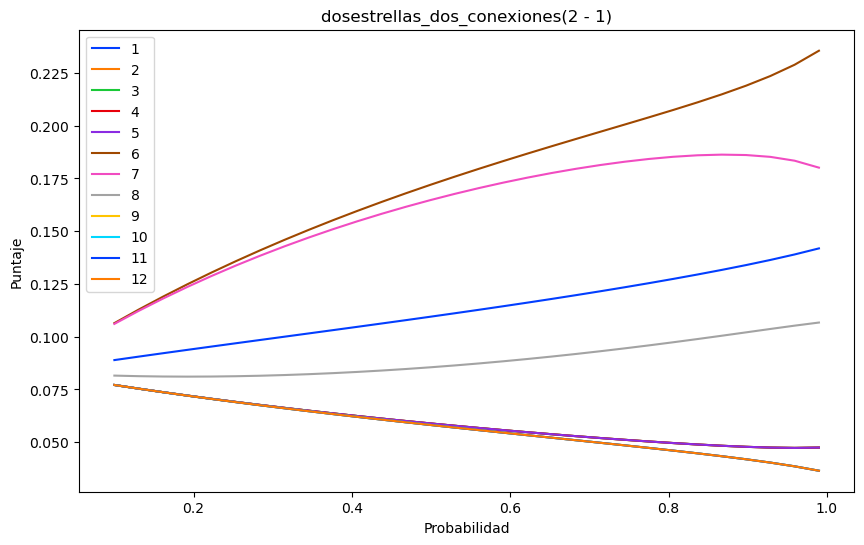

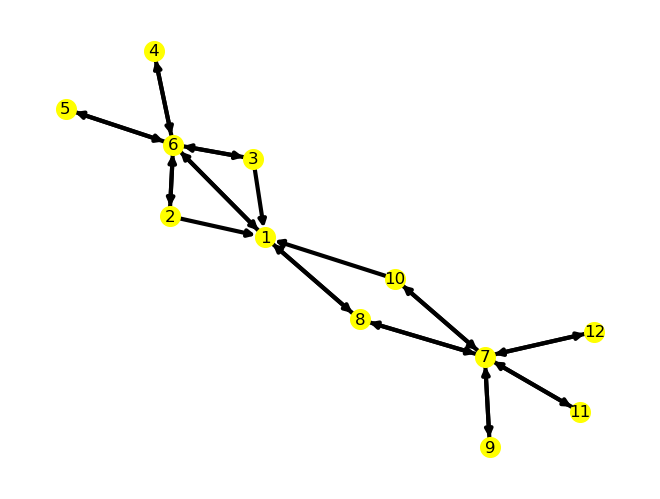

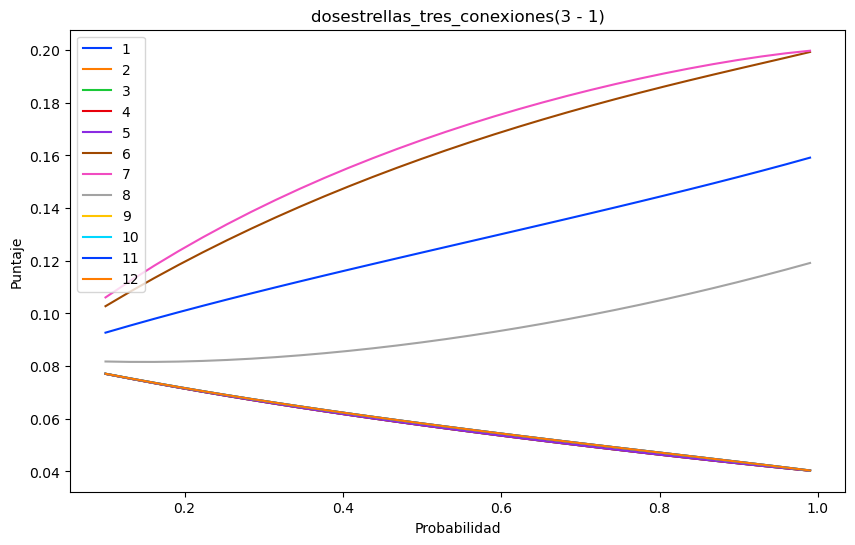

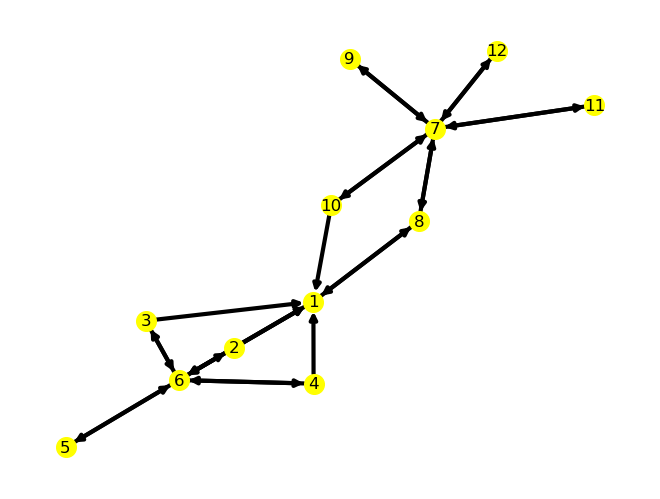

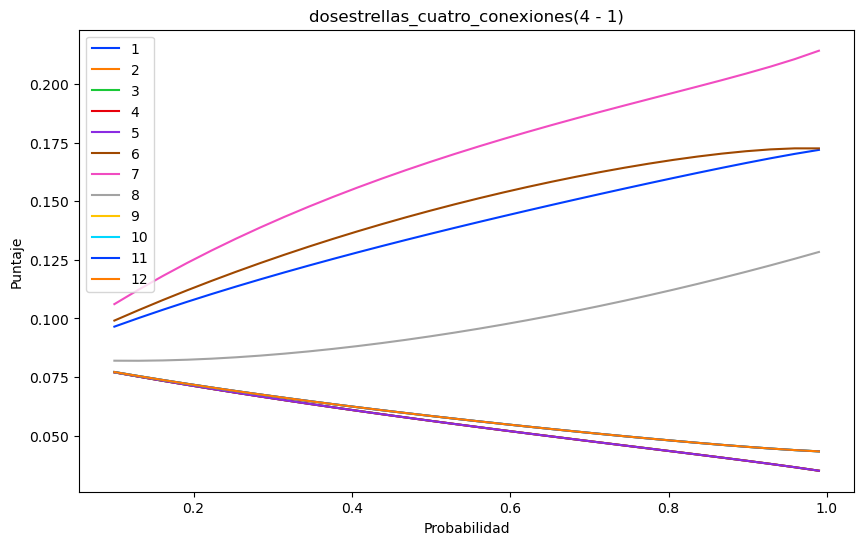

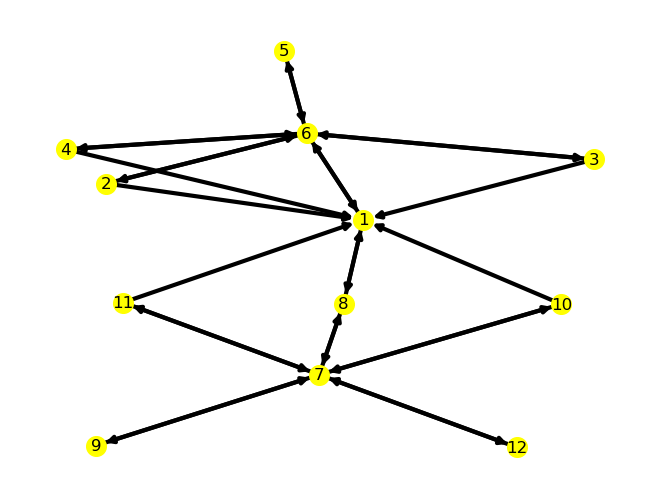

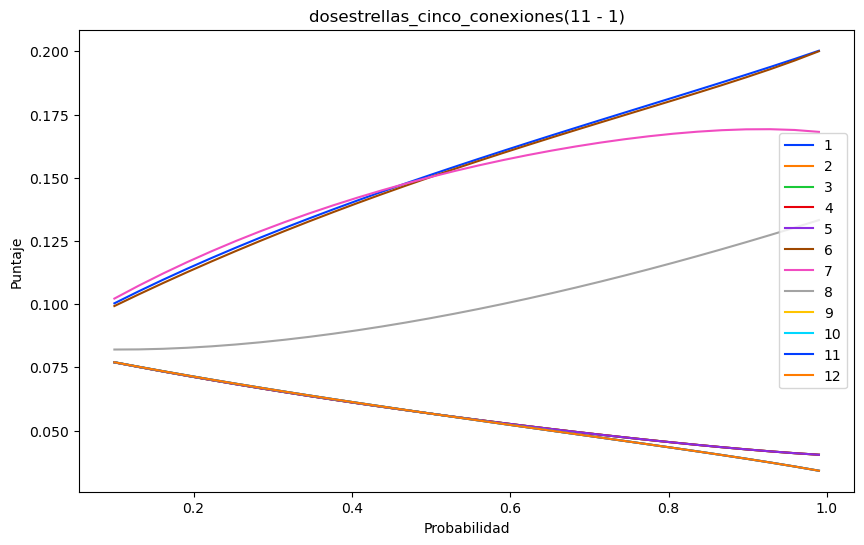

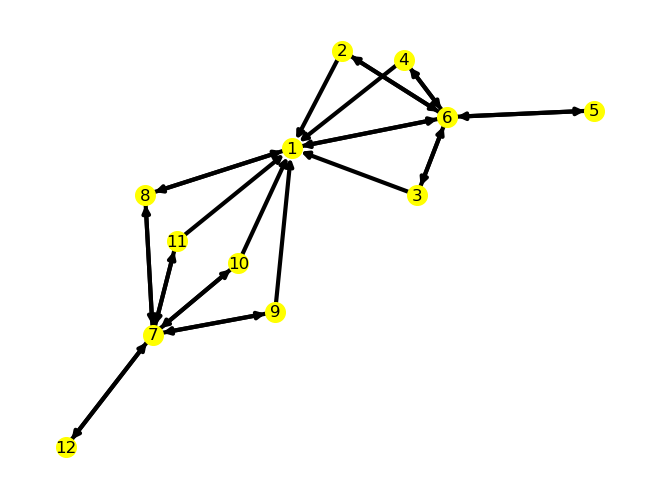

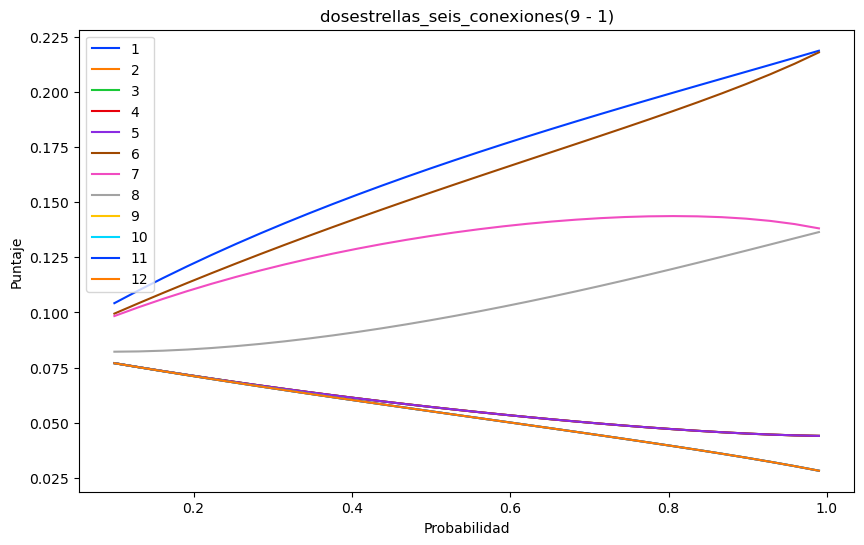

In [10]:
archivo_test= ['tests/test_dosestrellas.txt','tests/test_dosestrellas_1conexion.txt','tests/test_dosestrellas_2conexion.txt',
               'tests/test_dosestrellas_3conexion.txt','tests/test_dosestrellas_4conexion.txt','tests/test_dosestrellas_5conexion.txt',
               'tests/test_dosestrellas_6conexion.txt']

claves=['dosestrellas_original','dosestrellas_una_conexion(10 - 1)','dosestrellas_dos_conexiones(2 - 1)','dosestrellas_tres_conexiones(3 - 1)',
        'dosestrellas_cuatro_conexiones(4 - 1)', 'dosestrellas_cinco_conexiones(11 - 1)', 'dosestrellas_seis_conexiones(9 - 1)']

color=['violet','purple','blue','red','green','indigo','lightblue','orange']

p=np.linspace(0.1,0.99,30)

for i in range(len(claves)):
    W = leer_archivo(archivo_test[i])

    dibujarGrafo(W, print_ejes=False)

    dataset = pd.DataFrame(columns=np.arange(1, len(W)+1))

    for porcentaje in p:
        rnk, scr = calcularRanking(W, porcentaje)

        puntajes = pd.DataFrame(scr.transpose(), columns=np.arange(1, len(W)+1))

        dataset = pd.concat([dataset, puntajes], axis=0, ignore_index=True)

    dataset = pd.concat([dataset, pd.DataFrame(p, columns=["porcentaje"])], axis=1)

    columns = np.arange(0, len(W))

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.lineplot(x='porcentaje', y='value', hue='variable',
                data=pd.melt(dataset, ['porcentaje']),
                palette=sns.color_palette("bright", len(W)))

    plt.xlabel('Probabilidad')
    plt.ylabel('Puntaje')
    plt.title(claves[i])
    plt.yticks(rotation=0)
    plt.legend()
    plt.show()